# Gözetimsiz Öğrenme ile Müşteri Segmentasyonu

## İş Problemi

FLO müşterilerini segmentlere ayırıp bu segmentlere göre pazarlama stratejileri belirlemek istiyor. Buna yönelik olarak müşterilerin davranışları tanımlanacak ve bu davranışlardaki öbeklenmelere göre gruplar oluşturulacak.

Bu sefer elimizde **etiket yok** (average / highlighted gibi bir hedef değişken yok). Model, benzer alışveriş davranışındaki müşterileri kendi başına kümeler.

## Veri Seti Hikayesi

Veri seti Flo’dan son alışverişlerini **2020–2021** yıllarında OmniChannel (hem online hem offline alışveriş yapan) olarak yapan müşterilerin geçmiş alışveriş davranışlarından elde edilen bilgilerden oluşmaktadır.

**12 Değişken, 19.945 Gözlem, 2.7 MB**

| Değişken | Açıklama |
|---|---|
| master_id | Eşsiz müşteri numarası |
| order_channel | Alışveriş yapılan platforma ait hangi kanalın kullanıldığı (Android, ios, Desktop, Mobile) |
| last_order_channel | En son alışverişin yapıldığı kanal |
| first_order_date | Müşterinin yaptığı ilk alışveriş tarihi |
| last_order_date | Müşterinin yaptığı son alışveriş tarihi |
| last_order_date_online | Müşterinin online platformda yaptığı son alışveriş tarihi |
| last_order_date_offline | Müşterinin offline platformda yaptığı son alışveriş tarihi |
| order_num_total_ever_online | Müşterinin online platformda yaptığı toplam alışveriş sayısı |
| order_num_total_ever_offline | Müşterinin offline'da yaptığı toplam alışveriş sayısı |
| customer_value_total_ever_offline | Müşterinin offline alışverişlerinde ödediği toplam ücret |
| customer_value_total_ever_online | Müşterinin online alışverişlerinde ödediği toplam ücret |
| interested_in_categories_12 | Müşterinin son 12 ayda alışveriş yaptığı kategorilerin listesi |

## Proje Görevleri

- **Görev 1:** Veriyi hazırlama
  - Adım 1: `flo_data_20k.csv` verisini okutunuz.
  - Adım 2: Müşterileri segmentlerken kullanacağınız değişkenleri seçiniz. Tenure (müşteri yaşı), Recency (en son kaç gün önce alışveriş yaptığı) gibi yeni değişkenler oluşturabilirsiniz.
- **Görev 2:** K-Means ile müşteri segmentasyonu
  - Adım 1: Değişkenleri standartlaştırınız.
  - Adım 2: Optimum küme sayısını belirleyiniz.
  - Adım 3: Modeli oluşturunuz ve müşterileri segmentleyiniz.
  - Adım 4: Her bir segmenti istatistiksel olarak inceleyiniz.
- **Görev 3:** Hierarchical Clustering ile müşteri segmentasyonu
  - Adım 1: Görev 2'de standartlaştırdığınız dataframe'i kullanarak optimum küme sayısını belirleyiniz.
  - Adım 2: Modeli oluşturunuz ve müşterileri segmentleyiniz.
  - Adım 3: Her bir segmenti istatistiksel olarak inceleyiniz.

In [1]:
# Sayısal işlemler için NumPy
import numpy as np

# Tablo (DataFrame) işlemleri için Pandas
import pandas as pd

# Görselleştirme
import matplotlib.pyplot as plt
import seaborn as sns

# Uyarı mesajlarını bastır (çıktıyı sadeleştirir; hataları saklamaz)
import warnings
warnings.filterwarnings("ignore")

# K-Means: benzer müşterileri K gruba ayırır
from sklearn.cluster import KMeans, AgglomerativeClustering

# Mesafe tabanlı kümeleme adil olsun diye ölçeklendirme
from sklearn.preprocessing import StandardScaler

# Elbow grafiğinde "dirsek" noktasını otomatik işaretler
from yellowbrick.cluster import KElbowVisualizer

# Hiyerarşik kümeleme: önce birleşme ağacı (dendrogram), sonra kesme
from scipy.cluster.hierarchy import linkage, dendrogram

# --- Pandas görüntüleme ayarları ---
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 500)
pd.set_option("display.float_format", lambda x: "%.3f" % x)
pd.set_option("future.infer_string", False)

# Görev 1: Veriyi Hazırlama

### Adım 1: `flo_data_20k.csv` verisini okutunuz.

In [2]:
# FLO OmniChannel müşteri verisini oku.
# Her satır bir müşteri; etiket (segment) yok, onu biz üreteceğiz.
df = pd.read_csv("datasets/flo_data_20k.csv")

print("Shape:", df.shape)
df.head()

Shape: (19945, 12)


,master_id,order_channel,last_order_channel,first_order_date,last_order_date,last_order_date_online,last_order_date_offline,order_num_total_ever_online,order_num_total_ever_offline,customer_value_total_ever_offline,customer_value_total_ever_online,interested_in_categories_12
0,cc294636-19f0-11eb-8d74-000d3a38a36f,Android App,Offline,2020-10-30,2021-02-26,2021-02-21,2021-02-26,4.000,1.000,139.990,799.380,[KADIN]
1,f431bd5a-ab7b-11e9-a2fc-000d3a38a36f,Android App,Mobile,2017-02-08,2021-02-16,2021-02-16,2020-01-10,19.000,2.000,159.970,1853.580,"[ERKEK, COCUK, KADIN, AKTIFSPOR]"
2,69b69676-1a40-11ea-941b-000d3a38a36f,Android App,Android App,2019-11-27,2020-11-27,2020-11-27,2019-12-01,3.000,2.000,189.970,395.350,"[ERKEK, KADIN]"
3,1854e56c-491f-11eb-806e-000d3a38a36f,Android App,Android App,2021-01-06,2021-01-17,2021-01-17,2021-01-06,1.000,1.000,39.990,81.980,"[AKTIFCOCUK, COCUK]"
4,d6ea1074-f1f5-11e9-9346-000d3a38a36f,Desktop,Desktop,2019-08-03,2021-03-07,2021-03-07,2019-08-03,1.000,1.000,49.990,159.990,[AKTIFSPOR]


In [3]:
def check_df(dataframe, head=5):
    """Veri setine ilk bakış: boyut, tipler, eksik değer, özet istatistik."""
    print("##################### Shape #####################")
    print(dataframe.shape)
    print("##################### Types #####################")
    print(dataframe.dtypes)
    print("##################### Head #####################")
    print(dataframe.head(head))
    print("##################### NA #####################")
    print(dataframe.isnull().sum())
    print("##################### Quantiles #####################")
    print(dataframe.select_dtypes(include=["number"]).quantile([0, 0.05, 0.50, 0.95, 0.99, 1]).T)


check_df(df)

##################### Shape #####################
(19945, 12)
##################### Types #####################
master_id                             object
order_channel                         object
last_order_channel                    object
first_order_date                      object
last_order_date                       object
last_order_date_online                object
last_order_date_offline               object
order_num_total_ever_online          float64
order_num_total_ever_offline         float64
customer_value_total_ever_offline    float64
customer_value_total_ever_online     float64
interested_in_categories_12           object
dtype: object
##################### Head #####################
                              master_id order_channel last_order_channel first_order_date last_order_date last_order_date_online last_order_date_offline  order_num_total_ever_online  order_num_total_ever_offline  customer_value_total_ever_offline  customer_value_total_ever_online     

 **19.945** müşteri, **12** değişken, eksik değer yok. Sipariş ve harcama kuyruklu: online sipariş medyan 2, max 200; online harcama medyan ~286 TL, max ~45 bin TL. K-Means bu uçları ayrı küme yapmasın diye sonra log alacağız. Tarihler hâlâ string; bir sonraki adımda datetime'a çevrilecek.


### Adım 2: Müşterileri segmentlerken kullanacağınız değişkenleri seçiniz.

Not: Tenure (müşterinin yaşı), Recency (en son kaç gün önce alışveriş yaptığı) gibi yeni değişkenler oluşturabilirsiniz.

In [4]:
# Tarih sütunları şu an string. Gün farkı (recency, tenure) hesaplamak için datetime'a çeviriyoruz.
date_cols = [col for col in df.columns if "date" in col]
for col in date_cols:
    df[col] = pd.to_datetime(df[col])

print(df[date_cols].dtypes)
print("Son sipariş tarihi (max):", df["last_order_date"].max())

first_order_date           datetime64[us]
last_order_date            datetime64[us]
last_order_date_online     datetime64[us]
last_order_date_offline    datetime64[us]
dtype: object
Son sipariş tarihi (max): 2021-05-30 00:00:00


Son sipariş **2021-05-30**. Recency'yi bu güne göre değil, +2 gün sonraki analiz anına göre ölçeceğiz; aksi halde o gün alışveriş yapanların recency'si 0 olur.


In [5]:
# Analiz tarihi: veri setindeki son siparişten 2 gün sonrası.
# "Bugün" diye son sipariş gününü almak recency=0 üretir; +2 gün daha gerçekçi bir analiz anı verir.
# (RFM notebook'undaki ile aynı kural.)
analysis_date = df["last_order_date"].max() + pd.DateOffset(days=2)
print("Analiz tarihi:", analysis_date)

# Recency: en son alışverişten bu yana geçen gün. Küçükse müşteri "sıcak".
df["recency"] = (analysis_date - df["last_order_date"]).dt.days

# Tenure: ilk alışverişten bu yana geçen gün. Müşterinin FLO'daki "yaşı".
df["tenure"] = (analysis_date - df["first_order_date"]).dt.days

# Frequency: online + offline toplam sipariş adedi.
df["frequency"] = df["order_num_total_ever_online"] + df["order_num_total_ever_offline"]

# Monetary: online + offline toplam harcama.
df["monetary"] = df["customer_value_total_ever_online"] + df["customer_value_total_ever_offline"]

df[["master_id", "recency", "tenure", "frequency", "monetary"]].head()

Analiz tarihi: 2021-06-01 00:00:00


,master_id,recency,tenure,frequency,monetary
0,cc294636-19f0-11eb-8d74-000d3a38a36f,95,214,5.000,939.370
1,f431bd5a-ab7b-11e9-a2fc-000d3a38a36f,105,1574,21.000,2013.550
2,69b69676-1a40-11ea-941b-000d3a38a36f,186,552,5.000,585.320
3,1854e56c-491f-11eb-806e-000d3a38a36f,135,146,2.000,121.970
4,d6ea1074-f1f5-11e9-9346-000d3a38a36f,86,668,2.000,209.980


Analiz tarihi **2021-06-01**. Recency = bu tarih − son sipariş; tenure = bu tarih − ilk sipariş; frequency / monetary = online + offline toplamlar. Segmentasyon bu dört davranış metriği üzerinden gidecek.


In [6]:
# Kümelemede kullanacağımız 4 davranış metriği.
# master_id kimliktir, kanallar kategoriktir, kategori listesi metindir: mesafeye girmezler.
cluster_cols = ["recency", "tenure", "frequency", "monetary"]
model_df = df[cluster_cols].copy()

print(model_df.describe([0.01, 0.05, 0.50, 0.95, 0.99]).T)

# Frequency ve monetary sağa çarpık (birkaç yüksek harcayan kuyruğu uzatır).
# K-Means mesafeye bakıyor; log1p bu kuyruğu sıkıştırır, kümeler outlier'a esir olmaz.
model_df_log = np.log1p(model_df)
model_df_log.head()

              count    mean     std    min      1%      5%     50%      95%      99%       max
recency   19945.000 134.458 103.281  2.000   4.000   9.000 111.000  335.000  360.000   367.000
tenure    19945.000 801.303 523.397  5.000  83.440 209.200 651.000 2074.000 2605.000  3060.000
frequency 19945.000   5.025   4.743  2.000   2.000   2.000   4.000   12.000   22.000   202.000
monetary  19945.000 751.244 895.402 44.980 113.980 175.480 545.270 1921.924 3606.356 45905.100


,recency,tenure,frequency,monetary
0,4.564,5.371,1.792,6.846
1,4.663,7.362,3.091,7.608
2,5.231,6.315,1.792,6.374
3,4.913,4.990,1.099,4.812
4,4.466,6.506,1.099,5.352


Ham ölçekler çok farklı: recency ortalama **134 gün**, tenure **801 gün**, frequency **5 sipariş**, monetary **751 TL** (max 45.905). %99'luk müşteri 22 sipariş / ~3.600 TL iken kuyruk bunu 10 kat aşıyor. `log1p` sonrası değerler birbirine yaklaştı (ör. monetary 6–7 bandı); StandardScaler artık adil mesafe hesaplayabilir.


# Görev 2: K-Means ile Müşteri Segmentasyonu

### Adım 1: Değişkenleri standartlaştırınız.

In [7]:
# StandardScaler: her sütunu ortalama 0, standart sapma 1 yapar.
# Neden? Monetary yüzlerce/binlerce TL, recency onlarca gün.
# Ölçeklemezsek K-Means neredeyse yalnızca harcamaya göre kümeler.
scaler = StandardScaler()
df_scaled = scaler.fit_transform(model_df_log)

print("Ölçeklenmiş shape:", df_scaled.shape)
print(df_scaled[:5])

Ölçeklenmiş shape: (19945, 4)
[[ 0.08098845 -1.75341155  0.29245102  0.70538611]
 [ 0.17207134  1.3410868   2.93629933  1.74953277]
 [ 0.69386478 -0.28536156  0.29245102  0.05795554]
 [ 0.40114682 -2.34423275 -1.11800077 -2.08264924]
 [-0.00949621  0.01055149 -1.11800077 -1.34282671]]


Ölçeklenmiş matris **(19945, 4)**: her müşteri dört standart sapmalı eksende bir nokta. Bundan sonra K-Means ve hierarchical aynı `df_scaled` üzerinde çalışacak.


### Adım 2: Optimum küme sayısını belirleyiniz.

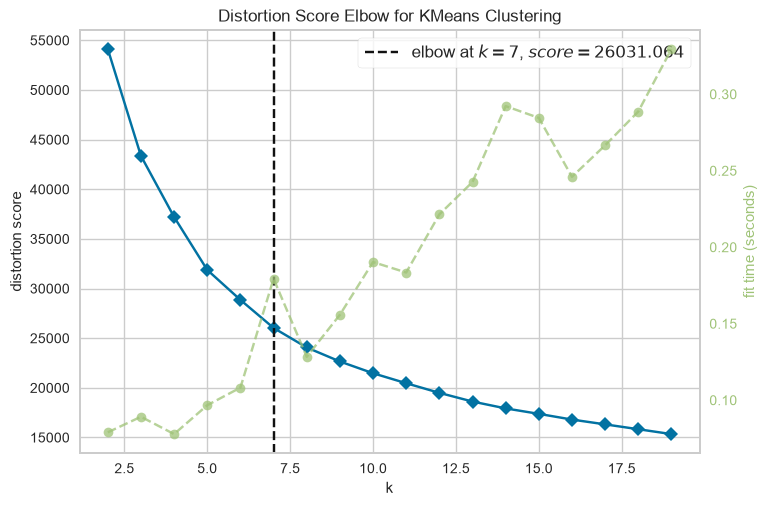

Önerilen küme sayısı (elbow): 7


In [8]:
# Elbow (dirsek) yöntemi: K arttıkça toplam hata (inertia) düşer.
# Grafikte düşüşün yavaşladığı "dirsek" noktası, fazla bölmeden önceki son kazançtır.
kmeans = KMeans(n_init=10, random_state=17)
elbow = KElbowVisualizer(kmeans, k=(2, 20), force_model=True)
elbow.fit(df_scaled)
elbow.show()

print("Önerilen küme sayısı (elbow):", elbow.elbow_value_)

Elbow **K = 7** önerdi. 2–20 arasından dirseğin kırıldığı yer burası; daha fazla küme hatayı az düşürür, pazarlama tarafında da 7 grup hâlâ yönetilebilir.


### Adım 3: Modelinizi oluşturunuz ve müşterilerinizi segmentleyiniz.

In [9]:
# Elbow'un önerdiği K ile final K-Means.
# random_state=17: her çalıştırmada aynı başlangıç, aynı kümeler.
kmeans_final = KMeans(
    n_clusters=elbow.elbow_value_,
    n_init=10,
    random_state=17
).fit(df_scaled)

print("Küme sayısı:", kmeans_final.n_clusters)
print("Inertia (toplam karesel hata):", round(kmeans_final.inertia_, 2))

# labels_ 0'dan başlar; raporda 1'den başlatmak daha okunaklı.
df["kmeans_segment"] = kmeans_final.labels_ + 1

print(df["kmeans_segment"].value_counts().sort_index())
df[["master_id", "recency", "tenure", "frequency", "monetary", "kmeans_segment"]].head()

Küme sayısı: 7
Inertia (toplam karesel hata): 26031.11
kmeans_segment
1    2237
2    4906
3    2606
4    1873
5    1793
6    5379
7    1151
Name: count, dtype: int64


,master_id,recency,tenure,frequency,monetary,kmeans_segment
0,cc294636-19f0-11eb-8d74-000d3a38a36f,95,214,5.000,939.370,2
1,f431bd5a-ab7b-11e9-a2fc-000d3a38a36f,105,1574,21.000,2013.550,5
2,69b69676-1a40-11ea-941b-000d3a38a36f,186,552,5.000,585.320,2
3,1854e56c-491f-11eb-806e-000d3a38a36f,135,146,2.000,121.970,7
4,d6ea1074-f1f5-11e9-9346-000d3a38a36f,86,668,2.000,209.980,6


 7 segment, boyutlar dengesiz: en kalabalık **6 (5.379)** ve **2 (4.906)**; en küçük **7 (1.151)** ve **5 (1.793)**. Küçük kümeler genelde yeni müşteri veya VIP gibi uç profillerdir; büyüklüğe bakıp silmeyiz, istatistiğe bakarız.


### Adım 4: Her bir segmenti istatistiksel olarak inceleyiniz.

In [10]:
# Ham (log'suz) metriklerle bakıyoruz: pazarlama ekibi gün, adet ve TL anlar.
kmeans_summary = df.groupby("kmeans_segment").agg(
    musteri_sayisi=("master_id", "count"),
    recency_mean=("recency", "mean"),
    recency_median=("recency", "median"),
    tenure_mean=("tenure", "mean"),
    tenure_median=("tenure", "median"),
    frequency_mean=("frequency", "mean"),
    frequency_median=("frequency", "median"),
    monetary_mean=("monetary", "mean"),
    monetary_median=("monetary", "median"),
)

kmeans_summary

,musteri_sayisi,recency_mean,recency_median,tenure_mean,tenure_median,frequency_mean,frequency_median,monetary_mean,monetary_median
kmeans_segment,,,,,,,,,
1,2237,23.926,22.000,776.467,673.000,7.025,7.000,1154.391,1037.870
2,4906,173.426,160.000,658.561,642.000,4.964,5.000,802.413,729.785
3,2606,26.916,25.000,626.836,594.000,3.047,3.000,426.470,409.955
4,1873,186.440,181.000,1792.741,1694.000,4.737,4.000,587.568,548.690
5,1793,121.398,98.000,1389.587,1290.000,14.851,12.000,2241.773,1786.940
6,5379,197.919,187.000,624.586,597.000,2.524,2.000,310.040,299.950
7,1151,65.859,55.000,149.098,151.000,2.722,2.000,491.277,396.800



| Segment | n | Recency | Tenure | Freq | Monetary | Okuma |
|---|---|---|---|---|---|---|
| **1** | 2.237 | **24 gün** | 776 | 7 | **1.154 TL** | Sıcak, sık alan, yüksek harcayan → sadık / champions |
| **2** | 4.906 | 173 | 659 | 5 | 802 | Orta değer, uzun süredir yok → risk / uyandırma |
| **3** | 2.606 | **27 gün** | 627 | 3 | 426 | Yeni gelmiş ama henüz az harcıyor → büyütme adayı |
| **4** | 1.873 | 186 | **1.793 gün** | 5 | 588 | Eski müşteri, uykuda → win-back |
| **5** | 1.793 | 121 | 1.390 | **15** | **2.242 TL** | En kârlı, en sık alan → VIP, kaybetme |
| **6** | 5.379 | **198 gün** | 625 | **2,5** | **310 TL** | En büyük grup: düşük değer, uzak → ucuz reaktivasyon veya bırak |
| **7** | 1.151 | 66 | **149 gün** | 2,7 | 491 | Kısa tenure → yeni müşteri, onboarding |

Pazarlama için asıl ayrım: **5 ve 1'i tut**, **7'yi alıştır**, **2 ve 4'ü geri çağır**, **6'ya bütçe yakma**.


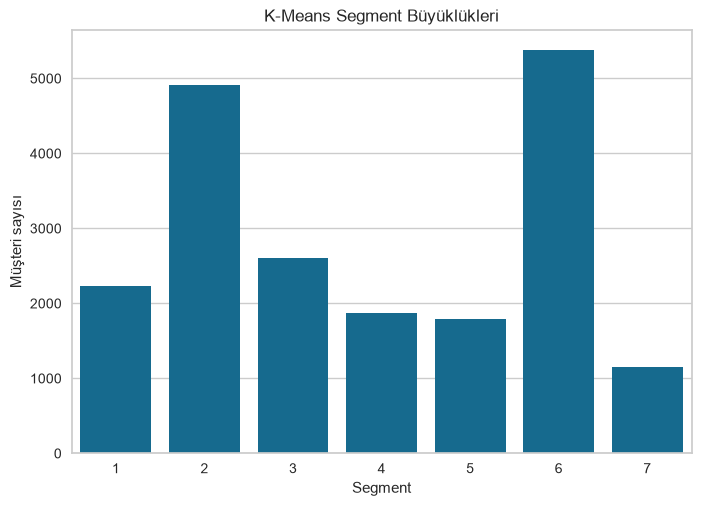

In [11]:
# Segment büyüklükleri: çok küçük bir küme genelde outlier grubudur.
sns.countplot(x="kmeans_segment", data=df, order=sorted(df["kmeans_segment"].unique()))
plt.title("K-Means Segment Büyüklükleri")
plt.xlabel("Segment")
plt.ylabel("Müşteri sayısı")
plt.show()

# Okuma anahtarı (ortalamalara göre yorumla):
# - Düşük recency + yüksek frequency/monetary  -> sadık / yüksek değerli
# - Yüksek recency + düşük frequency           -> uykuda / kayıp riski
# - Düşük tenure + düşük frequency             -> yeni müşteri
# - Yüksek tenure + yüksek monetary            -> uzun soluklu, kârlı

Grafik de aynı dağılımı gösteriyor: 6 ve 2 gövde, 7 ince kuyruk. Denge aramıyoruz; FLO'da çoğu müşteri düşük frekanslı omnichannel alıcı, VIP azınlık.


# Görev 3: Hierarchical Clustering ile Müşteri Segmentasyonu

### Adım 1: Görev 2'de standartlaştırdığınız dataframe'i kullanarak optimum küme sayısını belirleyiniz.

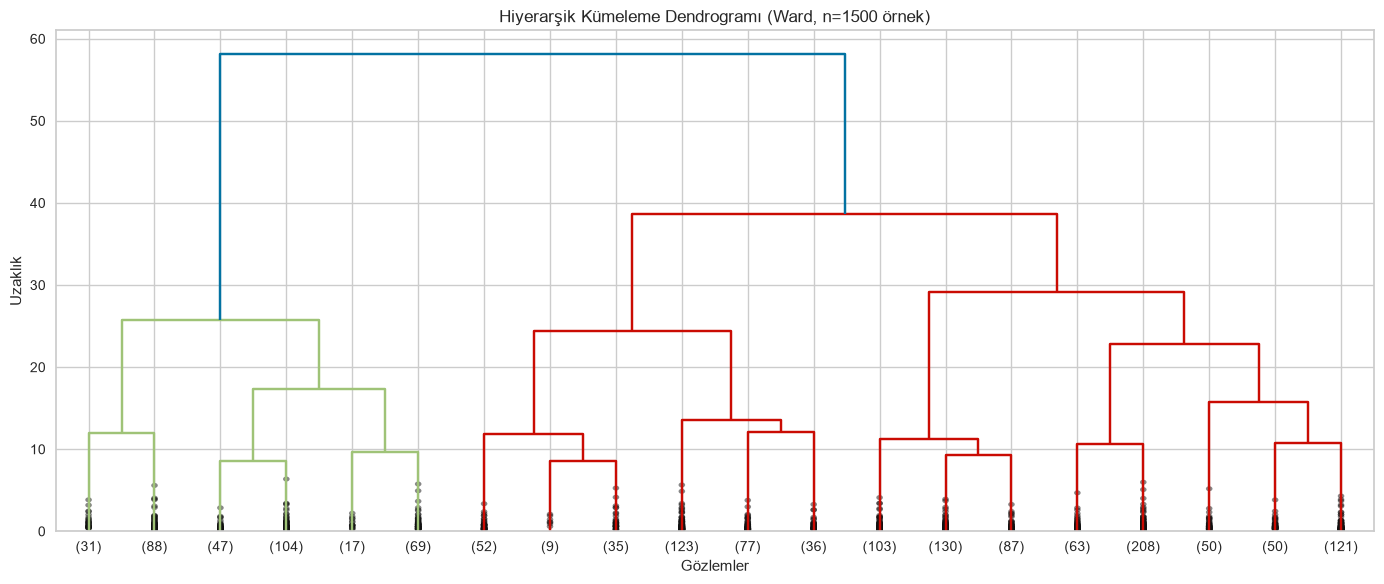

In [12]:
# Dendrogram 20 bin müşteride hem yavaş hem okunaksız (O(n²) bellek).
# Aynı ölçeklenmiş uzaydan 1.500 kişilik rastgele örnekle ağacı çiziyoruz.
# Ward: birleşince küme içi varyansı en az artıran çiftleri birleştirir.
rng = np.random.RandomState(17)
sample_idx = rng.choice(df_scaled.shape[0], size=1500, replace=False)
df_scaled_sample = df_scaled[sample_idx]

hc_ward = linkage(df_scaled_sample, method="ward")

plt.figure(figsize=(14, 6))
plt.title("Hiyerarşik Kümeleme Dendrogramı (Ward, n=1500 örnek)")
plt.xlabel("Gözlemler")
plt.ylabel("Uzaklık")
dendrogram(hc_ward, truncate_mode="lastp", p=20, leaf_font_size=10, show_contracted=True)
plt.tight_layout()
plt.show()

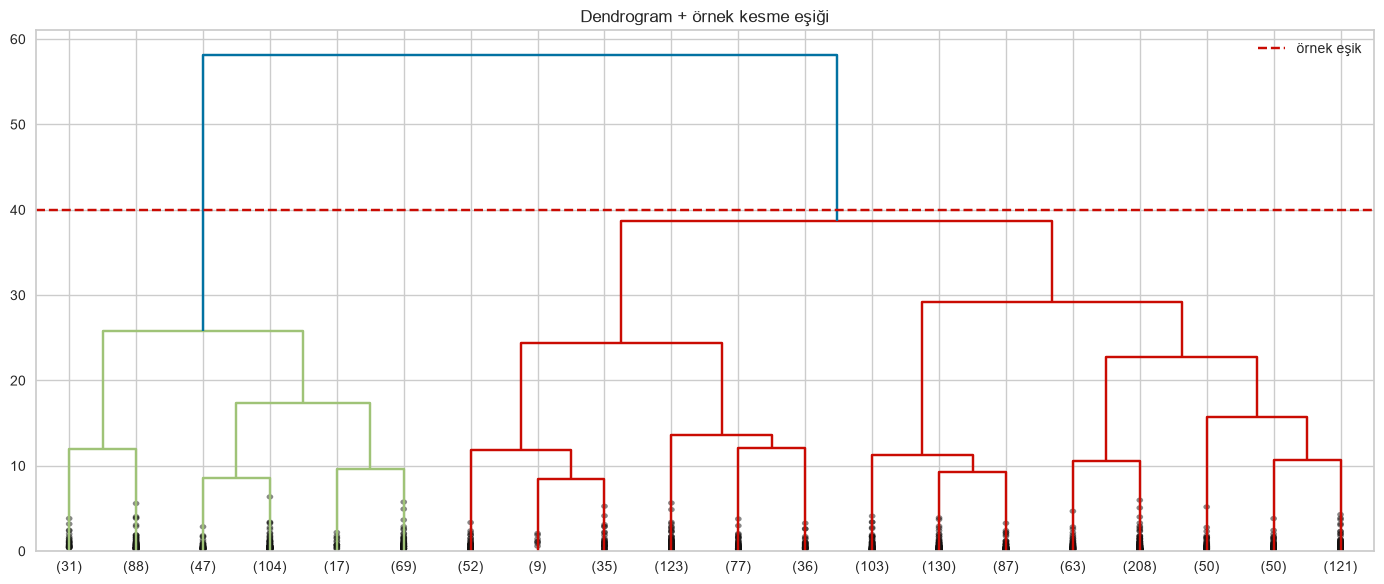

Hiyerarşik kümeleme için kullanılacak küme sayısı: 7


In [13]:
# Dendrogramda uzun dikey boşluk = kümeler orada hâlâ uzak, kesmek mantıklı.
# Aşağıdaki eşik çizgisi görsel bir örnektir; kestiği dal sayısı önerilen K'dir.
plt.figure(figsize=(14, 6))
dendrogram(hc_ward, truncate_mode="lastp", p=20, leaf_font_size=10, show_contracted=True)
plt.axhline(y=40, color="r", linestyle="--", label="örnek eşik")
plt.title("Dendrogram + örnek kesme eşiği")
plt.legend()
plt.tight_layout()
plt.show()

# K-Means elbow ile hizalı gidelim; iki yöntem aynı K'de kıyaslanır.
hc_n_clusters = elbow.elbow_value_
print("Hiyerarşik kümeleme için kullanılacak küme sayısı:", hc_n_clusters)

Dendrogramda üstteki uzun dikey boşluklar 5–8 kümeyi işaret ediyor. K-Means ile kıyas için **aynı K = 7** kesiyoruz; böylece fark algoritmadan, K seçiminden değil.


### Adım 2: Modelinizi oluşturunuz ve müşterilerinizi segmentleyiniz.

In [14]:
# AgglomerativeClustering: alttan üste birleştirir, n_clusters'ta durur.
# linkage="ward" dendrogramdaki yöntemle aynıdır.
# Tüm müşterilere etiket vermek için ölçeklenmiş tam tabloyu kullanıyoruz.
hc_model = AgglomerativeClustering(n_clusters=hc_n_clusters, linkage="ward")
hc_labels = hc_model.fit_predict(df_scaled)

df["hc_segment"] = hc_labels + 1

print(df["hc_segment"].value_counts().sort_index())
df[["master_id", "recency", "tenure", "frequency", "monetary", "kmeans_segment", "hc_segment"]].head()

hc_segment
1    2150
2    3938
3    5370
4    1334
5    3230
6    1611
7    2312
Name: count, dtype: int64


,master_id,recency,tenure,frequency,monetary,kmeans_segment,hc_segment
0,cc294636-19f0-11eb-8d74-000d3a38a36f,95,214,5.000,939.370,2,4
1,f431bd5a-ab7b-11e9-a2fc-000d3a38a36f,105,1574,21.000,2013.550,5,1
2,69b69676-1a40-11ea-941b-000d3a38a36f,186,552,5.000,585.320,2,3
3,1854e56c-491f-11eb-806e-000d3a38a36f,135,146,2.000,121.970,7,4
4,d6ea1074-f1f5-11e9-9346-000d3a38a36f,86,668,2.000,209.980,6,2


Hierarchical da 7 grup üretti ama boyutlar kaydı: en kalabalık **3 (5.370)**, en küçük **4 (1.334)**. Ward birleştirerek büyüttüğü için K-Means'teki gibi küre varsaymaz; sınırdaki müşteri başka numaraya düşebilir.


### Adım 3: Her bir segmenti istatistiksel olarak inceleyiniz.

In [15]:
hc_summary = df.groupby("hc_segment").agg(
    musteri_sayisi=("master_id", "count"),
    recency_mean=("recency", "mean"),
    recency_median=("recency", "median"),
    tenure_mean=("tenure", "mean"),
    tenure_median=("tenure", "median"),
    frequency_mean=("frequency", "mean"),
    frequency_median=("frequency", "median"),
    monetary_mean=("monetary", "mean"),
    monetary_median=("monetary", "median"),
)

hc_summary

,musteri_sayisi,recency_mean,recency_median,tenure_mean,tenure_median,frequency_mean,frequency_median,monetary_mean,monetary_median
hc_segment,,,,,,,,,
1,2150,58.894,31.000,1088.525,831.000,13.054,11.000,2045.249,1657.865
2,3938,32.353,26.000,656.570,612.000,3.568,3.000,515.926,465.315
3,5370,190.407,184.000,625.667,609.000,3.546,3.000,560.754,515.520
4,1334,78.855,70.000,170.423,168.000,2.661,2.000,483.213,349.970
5,3230,146.847,127.000,993.672,802.000,7.434,7.000,1131.631,1034.450
6,1611,193.601,194.000,1730.307,1658.000,3.668,3.000,442.735,400.480
7,2312,222.258,210.500,636.601,625.000,2.418,2.000,229.367,229.970



| HC | n | Recency | Tenure | Freq | Monetary | Yakın K-Means |
|---|---|---|---|---|---|---|
| **1** | 2.150 | 59 | 1.089 | **13** | **2.045 TL** | VIP (KM 5 + kısmen 1) |
| **2** | 3.938 | **32** | 657 | 3,6 | 516 | Sıcak ama düşük harcama (KM 3) |
| **3** | 5.370 | 190 | 626 | 3,5 | 561 | Uykuda orta (KM 2 / 6) |
| **4** | 1.334 | 79 | **170** | 2,7 | 483 | Yeni müşteri (KM 7) |
| **5** | 3.230 | 147 | 994 | 7,4 | 1.132 | Yüksek değer, soğumuş (KM 1 / 5) |
| **6** | 1.611 | 194 | **1.730** | 3,7 | 443 | Eski ve uykuda (KM 4) |
| **7** | 2.312 | **222** | 637 | **2,4** | **229 TL** | En düşük değer, en uzak (KM 6) |


K-Means vs Hierarchical çapraz tablo:
hc_segment         1     2     3     4     5     6     7
kmeans_segment                                          
1               1141   852     0     2   233     9     0
2                 18   260  2859    28  1737     4     0
3                  0  2373   179    20     0    29     5
4                  0    12   148     0   453  1258     2
5                986     0     0     1   806     0     0
6                  0   430  2134   199     0   311  2305
7                  5    11    50  1084     1     0     0


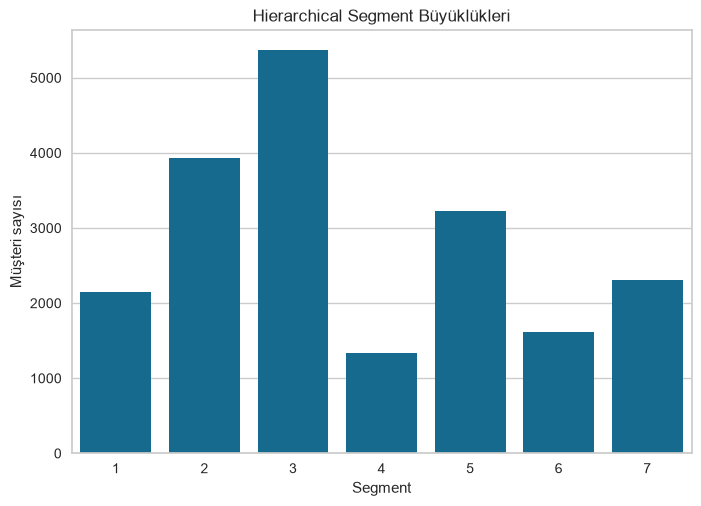

In [16]:
# İki algoritma aynı müşteriyi aynı segmente koymak zorunda değil.
# Çapraz tablo: örtüşme yüksekse yapı veriye ait, yönteme değil.
print("K-Means vs Hierarchical çapraz tablo:")
print(pd.crosstab(df["kmeans_segment"], df["hc_segment"]))

sns.countplot(x="hc_segment", data=df, order=sorted(df["hc_segment"].unique()))
plt.title("Hierarchical Segment Büyüklükleri")
plt.xlabel("Segment")
plt.ylabel("Müşteri sayısı")
plt.show()

İki yöntem aynı müşteriyi aynı *numaraya* koymuyor; ama aynı *hikâyeye* koyuyor:

- Yeni müşteri: KM **7** ↔ HC **4** (1.084 / 1.151)
- Eski uykuda: KM **4** ↔ HC **6** (1.258 / 1.873)
- VIP: KM **5** ↔ HC **1** ve **5**
- Champions: KM **1** ↔ HC **1** ve **2**
- Düşük değerli gövde: KM **6** ↔ HC **7** ve **3**

Yapı veriye ait. Kampanya tasarımında K-Means segmentlerini kullanmak yeterli; hierarchical teyit. Numaraları eşleştirmeden doğrudan "segment 1 = segment 1" deme.
